**Objective**

Predict whether a loan applicant is likely to fully repay or become charged off, so LoanTap can make an informed credit-underwriting decision.

**Target**

loan_status

**Good outcome**

Fully Paid

**Bad outcome**

Charged Off

**Primary business risk**

False Negative: predicting Fully Paid for an applicant who actually becomes Charged Off.

**Prediction point**

Immediately before the loan approval/underwriting decision, using information legitimately available at that point.

**Secondary objective**

Investigate whether the available data supports risk-adjusted repayment/loan terms.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

In [3]:
#!gdown 1ZPYj7CZCfxntE8p2Lze_4QO4MyEOy6_d

In [4]:
#data = pd.read_csv('/content/logistic_regression.csv')
data=pd.read_csv(r'C:\Users\sriha\Desktop\GitRepos\Loan Tap\logistic_regression.csv')

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
data.shape

(396030, 27)

In [7]:
data.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,Not Verified,Jan-2015,Fully Paid,vacation,Vacation,26.24,Jun-1990,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,Not Verified,Jan-2015,Fully Paid,debt_consolidation,Debt consolidation,22.05,Jul-2004,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,Source Verified,Jan-2015,Fully Paid,credit_card,Credit card refinancing,12.79,Aug-2007,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,Not Verified,Nov-2014,Fully Paid,credit_card,Credit card refinancing,2.60,Sep-2006,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,Verified,Apr-2013,Charged Off,credit_card,Credit Card Refinance,33.95,Mar-1999,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [9]:
data['issue_d']=pd.to_datetime(data['issue_d'])

In [10]:
data['earliest_cr_line']=pd.to_datetime(data['earliest_cr_line'])

In [11]:
data[['issue_d','earliest_cr_line']].isna().sum()

issue_d             0
earliest_cr_line    0
dtype: int64

# Investigating Nulls.

In [12]:
data.isna().sum()

loan_amnt                   0
term                        0
int_rate                    0
installment                 0
grade                       0
sub_grade                   0
emp_title               22927
emp_length              18301
home_ownership              0
annual_inc                  0
verification_status         0
issue_d                     0
loan_status                 0
purpose                     0
title                    1756
dti                         0
earliest_cr_line            0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                276
total_acc                   0
initial_list_status         0
application_type            0
mort_acc                37795
pub_rec_bankruptcies      535
address                     0
dtype: int64

Dealing with null value columns.

we have:

***Features***            ***Null Count***

*emp_title:*              **22927**

*emp_length:*              **18301**

*title:*                    **1756**

*revol_util:*               **276**

*mort_acc:*                **37795**

*pub_rec_bankruptcies:*     **535**

In [13]:
# % of missing values in each column.
cols=['emp_title','emp_length','title','revol_util','mort_acc','pub_rec_bankruptcies']
a=[print(f"{col}: {data[col].isnull().sum() / len(data) * 100:.2f}%") for col in cols]
print(a)

emp_title: 5.79%
emp_length: 4.62%
title: 0.44%
revol_util: 0.07%
mort_acc: 9.54%
pub_rec_bankruptcies: 0.14%
[None, None, None, None, None, None]


#### Investigating relationship of cols with null values to target variable.

In [14]:
missing_cols = [
    'emp_title',
    'emp_length',
    'title',
    'revol_util',
    'mort_acc',
    'pub_rec_bankruptcies'
]

for col in missing_cols:
    print(f"\n--- {col} ---")
    print(
        pd.crosstab(
            data[col].isna(),
            data['loan_status'],
            normalize='index'
        ) * 100
    )


--- emp_title ---
loan_status  Charged Off  Fully Paid
emp_title                           
False          19.225254   80.774746
True           25.921403   74.078597

--- emp_length ---
loan_status  Charged Off  Fully Paid
emp_length                          
False          19.229395   80.770605
True           27.528550   72.471450

--- title ---
loan_status  Charged Off  Fully Paid
title                               
False          19.616815   80.383185
True           18.735763   81.264237

--- revol_util ---
loan_status  Charged Off  Fully Paid
revol_util                          
False          19.610667   80.389333
True           22.826087   77.173913

--- mort_acc ---
loan_status  Charged Off  Fully Paid
mort_acc                            
False          20.132874   79.867126
True           14.684482   85.315518

--- pub_rec_bankruptcies ---
loan_status           Charged Off  Fully Paid
pub_rec_bankruptcies                         
False                   19.617441   80.382559


In [15]:
data.describe()

,loan_amnt,int_rate,installment,annual_inc,issue_d,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030,396030.000000,396030,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,2014-02-02 15:57:58.045602560,17.379514,1998-05-03 09:34:15.062495488,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
min,500.000000,5.320000,16.080000,0.000000e+00,2007-06-01 00:00:00,0.000000,1944-01-01 00:00:00,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,2013-05-01 00:00:00,11.280000,1994-10-01 00:00:00,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,2014-04-01 00:00:00,16.910000,1999-09-01 00:00:00,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,2015-03-01 00:00:00,22.980000,2003-04-01 00:00:00,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,2016-12-01 00:00:00,9999.000000,2013-10-01 00:00:00,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000
std,8357.441341,4.472157,250.727790,6.163762e+04,NaN,18.019092,NaN,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174


In [16]:
data.duplicated().sum()

np.int64(0)

<Axes: title={'center': 'Loan Status Distribution'}, xlabel='loan_status'>

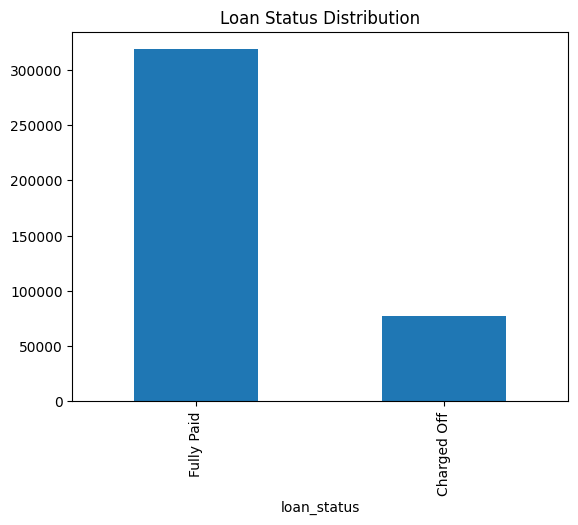

In [17]:
data['loan_status'].value_counts().plot(kind='bar', title='Loan Status Distribution')

In [18]:
data.select_dtypes(include='object').columns

Index(['term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'loan_status', 'purpose',
       'title', 'initial_list_status', 'application_type', 'address'],
      dtype='object')

In [19]:
data.select_dtypes(include='object').nunique().sort_values(ascending=False)

address                393700
emp_title              173105
title                   48816
sub_grade                  35
purpose                    14
emp_length                 11
grade                       7
home_ownership              6
application_type            3
verification_status         3
term                        2
loan_status                 2
initial_list_status         2
dtype: int64

In [20]:
low_car_categories = ['sub_grade','purpose','emp_length','home_ownership','verification_status','initial_list_status','application_type','grade','term']

for _ in low_car_categories:
    print(f"\n--- {_} ---")
    print(data[_].value_counts())


--- sub_grade ---
sub_grade
B3    26655
B4    25601
C1    23662
C2    22580
B2    22495
B5    22085
C3    21221
C4    20280
B1    19182
A5    18526
C5    18244
D1    15993
A4    15789
D2    13951
D3    12223
D4    11657
A3    10576
A1     9729
D5     9700
A2     9567
E1     7917
E2     7431
E3     6207
E4     5361
E5     4572
F1     3536
F2     2766
F3     2286
F4     1787
F5     1397
G1     1058
G2      754
G3      552
G4      374
G5      316
Name: count, dtype: int64

--- purpose ---
purpose
debt_consolidation    234507
credit_card            83019
home_improvement       24030
other                  21185
major_purchase          8790
small_business          5701
car                     4697
medical                 4196
moving                  2854
vacation                2452
house                   2201
wedding                 1812
renewable_energy         329
educational              257
Name: count, dtype: int64

--- emp_length ---
emp_length
10+ years    126041
2 years       358

In [21]:
data.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,396030.0,14113.888089,8357.441341,500.00,8000.00,12000.00,20000.00,40000.00
int_rate,396030.0,13.639400,4.472157,5.32,10.49,13.33,16.49,30.99
installment,396030.0,431.849698,250.727790,16.08,250.33,375.43,567.30,1533.81
annual_inc,396030.0,74203.175798,61637.621158,0.00,45000.00,64000.00,90000.00,8706582.00
dti,396030.0,17.379514,18.019092,0.00,11.28,16.91,22.98,9999.00
open_acc,396030.0,11.311153,5.137649,0.00,8.00,10.00,14.00,90.00
pub_rec,396030.0,0.178191,0.530671,0.00,0.00,0.00,0.00,86.00
revol_bal,396030.0,15844.539853,20591.836109,0.00,6025.00,11181.00,19620.00,1743266.00
revol_util,395754.0,53.791749,24.452193,0.00,35.80,54.80,72.90,892.30
total_acc,396030.0,25.414744,11.886991,2.00,17.00,24.00,32.00,151.00


In [22]:
data.nlargest(10,'dti')[['dti','annual_inc', 'loan_amnt', 'loan_status']]

,dti,annual_inc,loan_amnt,loan_status
285674,9999.00,0.0,3700.0,Charged Off
350865,1622.00,600.0,24000.0,Fully Paid
338571,380.53,5000.0,19000.0,Fully Paid
7011,189.90,2500.0,18375.0,Fully Paid
36015,145.65,8000.0,15100.0,Fully Paid
296164,138.03,16000.0,14000.0,Fully Paid
294182,120.66,8700.0,15000.0,Fully Paid
264045,107.55,6672.0,3200.0,Fully Paid
280972,93.86,8796.0,2000.0,Charged Off
317615,92.13,25000.0,19100.0,Fully Paid


In [23]:
data[data['annual_inc']==0][['annual_inc','dti','loan_status']]

,annual_inc,dti,loan_status
285674,0.0,9999.0,Charged Off


In [24]:
print(
    pd.crosstab(
        data['annual_inc'] == 0,
        data['dti'] == 9999,
        normalize='index'
    ) * 100
)

dti         False  True 
annual_inc              
False       100.0    0.0
True          0.0  100.0


##### This strongly suggest that the value dti = 9999 is sentinel value for annual_inc = 0.

In [25]:
data.nlargest(10,'annual_inc')[['annual_inc','dti', 'loan_amnt', 'loan_status']]

,annual_inc,dti,loan_amnt,loan_status
308700,8706582.0,0.11,8000.0,Charged Off
318255,7600000.0,0.09,10000.0,Fully Paid
100370,7446395.0,0.13,20000.0,Fully Paid
376306,7141778.0,0.25,14825.0,Fully Paid
100946,7000000.0,0.24,25000.0,Fully Paid
117632,6500000.0,0.25,25000.0,Charged Off
16169,6100000.0,0.22,30000.0,Fully Paid
165401,6000000.0,0.01,5000.0,Fully Paid
391587,6000000.0,0.16,4475.0,Fully Paid
308857,5000000.0,2.36,35000.0,Fully Paid


We Observe very high income values, possible outliers. Investigation is required to come to a conclusion.

In [26]:
data['annual_inc'].quantile([0.9, 0.93, 0.95, 0.97, 0.99,0.995,0.999, 1.0])

0.900     120000.0
0.930     136000.0
0.950     150000.0
0.970     175000.0
0.990     250000.0
0.995     300000.0
0.999     515000.0
1.000    8706582.0
Name: annual_inc, dtype: float64

annual_inc is strongly right-skewed with a long upper tail. Extreme values exist, but there is currently insufficient evidence to classify them as erroneous.

In [27]:
data.nlargest(10,'open_acc')[['open_acc','total_acc', 'dti', 'loan_amnt', 'loan_status']]

,open_acc,total_acc,dti,loan_amnt,loan_status
107918,90.0,107.0,31.99,30000.0,Fully Paid
273075,76.0,98.0,21.53,20000.0,Charged Off
322027,76.0,94.0,26.36,18950.0,Charged Off
72752,58.0,88.0,18.60,21000.0,Fully Paid
53317,57.0,135.0,33.85,24000.0,Fully Paid
127450,56.0,87.0,33.70,18225.0,Fully Paid
134084,56.0,79.0,9.47,20000.0,Fully Paid
187623,55.0,69.0,11.24,2200.0,Fully Paid
242593,55.0,94.0,26.40,28000.0,Fully Paid
81352,54.0,83.0,23.83,20000.0,Fully Paid


In [28]:
data['open_acc'].quantile([0.9, 0.93, 0.95, 0.97, 0.99,0.995,0.999, 1.0])

0.900    18.0
0.930    19.0
0.950    21.0
0.970    23.0
0.990    27.0
0.995    30.0
0.999    38.0
1.000    90.0
Name: open_acc, dtype: float64

In [29]:
data[data['open_acc']==90]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
107918,30000.0,60 months,12.39,673.27,C,C1,Senior Underwriter,3 years,MORTGAGE,115000.0,Verified,2015-01-01,Fully Paid,debt_consolidation,Debt consolidation,31.99,1982-04-01,90.0,0.0,128940.0,1.9,107.0,w,INDIVIDUAL,2.0,0.0,947 Matthew Meadow Suite 039\r\nNorth Joshuala...


Strongly right-skewed with rare extreme values. The maximum of 90 is unusual but internally plausible based on total_acc = 107; insufficient evidence to classify it as a data-entry error.

In [30]:
data.nlargest(10, 'pub_rec')[
    [
        'pub_rec',
        'pub_rec_bankruptcies',
        'open_acc',
        'total_acc',
        'annual_inc',
        'dti',
        'revol_util',
        'loan_amnt',
        'loan_status'
    ]
]

,pub_rec,pub_rec_bankruptcies,open_acc,total_acc,annual_inc,dti,revol_util,loan_amnt,loan_status
218818,86.0,1.0,13.0,19.0,38000.0,32.41,78.7,6400.0,Charged Off
127417,40.0,1.0,16.0,30.0,31000.0,33.60,9.1,5950.0,Charged Off
252783,24.0,0.0,10.0,22.0,96000.0,17.16,61.7,22425.0,Fully Paid
58202,19.0,1.0,11.0,20.0,56000.0,29.02,68.3,2000.0,Charged Off
112187,19.0,1.0,9.0,19.0,52000.0,16.99,61.6,5000.0,Charged Off
150704,17.0,1.0,13.0,22.0,101000.0,17.19,55.0,28000.0,Fully Paid
356214,15.0,0.0,5.0,9.0,73000.0,13.22,72.9,20000.0,Fully Paid
90433,13.0,0.0,11.0,34.0,67500.0,33.49,78.2,5000.0,Fully Paid
162670,13.0,0.0,10.0,17.0,100000.0,14.45,62.5,25000.0,Charged Off
216146,13.0,1.0,9.0,16.0,125000.0,16.18,51.2,20000.0,Fully Paid


In [31]:
data['pub_rec'].quantile([0.9, 0.93, 0.95, 0.97, 0.99,0.995,0.999, 1.0])

0.900     1.0
0.930     1.0
0.950     1.0
0.970     1.0
0.990     2.0
0.995     3.0
0.999     5.0
1.000    86.0
Name: pub_rec, dtype: float64

In [32]:
data['pub_rec'].value_counts().sort_values(ascending=False)

pub_rec
0.0     338272
1.0      49739
2.0       5476
3.0       1521
4.0        527
5.0        237
6.0        122
7.0         56
8.0         34
9.0         12
10.0        11
11.0         8
13.0         4
12.0         4
19.0         2
40.0         1
17.0         1
86.0         1
24.0         1
15.0         1
Name: count, dtype: int64

pub_rec is highly right-skewed. The value 86 is an extreme observation, but the associated credit variables are internally plausible and provide no clear evidence of data-entry error. Therefore, retain it provisionally rather than capping/removing it.

In [33]:
data.nlargest(10,'revol_util')[['revol_util','revol_bal', 'dti', 'loan_amnt', 'loan_status']]

,revol_util,revol_bal,dti,loan_amnt,loan_status
137211,892.3,2677.0,14.67,3500.0,Fully Paid
329037,153.0,16521.0,7.42,35000.0,Fully Paid
82600,152.5,13880.0,38.98,12000.0,Fully Paid
65687,150.7,9344.0,20.94,10000.0,Fully Paid
350333,148.0,20133.0,15.16,25000.0,Charged Off
165111,146.1,20033.0,11.56,12600.0,Fully Paid
312268,145.8,7000.0,8.58,8000.0,Fully Paid
296174,140.4,27233.0,26.35,12000.0,Fully Paid
108246,136.7,4100.0,6.96,10000.0,Charged Off
211426,132.1,18632.0,28.67,9175.0,Charged Off


In [34]:
data['revol_util'].quantile([0.9, 0.93, 0.95, 0.97, 0.99,0.995,0.999, 1.0])

0.900     86.2
0.930     89.5
0.950     92.0
0.970     94.7
0.990     98.0
0.995     99.3
0.999    102.0
1.000    892.3
Name: revol_util, dtype: float64

In [35]:
data[data['revol_util']==892.3][['revol_util','revol_bal', 'dti', 'loan_amnt', 'loan_status','annual_inc']]

,revol_util,revol_bal,dti,loan_amnt,loan_status,annual_inc
137211,892.3,2677.0,14.67,3500.0,Fully Paid,45000.0


In [36]:
data[data['revol_util']==892.3]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
137211,3500.0,36 months,12.49,117.08,B,B4,Budget Analyst,10+ years,RENT,45000.0,Verified,2014-04-01,Fully Paid,debt_consolidation,Debt consolidation,14.67,1998-10-01,2.0,0.0,2677.0,892.3,9.0,f,INDIVIDUAL,0.0,0.0,"12506 Connie Burg\r\nVelasquezfort, TN 00813"


revol_util is heavily right-skewed. The extreme value (~892%) appears inconsistent with the associated credit-profile variables and is therefore suspected to be a data-entry/data-quality error.

In [37]:
data.nsmallest(10,'annual_inc')[['annual_inc', 'loan_amnt', 'loan_status','installment','dti']]

,annual_inc,loan_amnt,loan_status,installment,dti
285674,0.0,3700.0,Charged Off,123.94,9999.00
350865,600.0,24000.0,Fully Paid,764.99,1622.00
7011,2500.0,18375.0,Fully Paid,552.77,189.90
72405,4000.0,2000.0,Fully Paid,67.61,6.00
127390,4000.0,1000.0,Charged Off,35.65,22.52
206061,4080.0,1400.0,Charged Off,46.41,13.24
2236,4200.0,1200.0,Fully Paid,40.28,4.29
363844,4524.0,2250.0,Charged Off,88.27,36.87
64370,4800.0,1000.0,Fully Paid,24.73,20.75
159591,4800.0,1200.0,Charged Off,41.17,13.75


In [38]:
data.nsmallest(10, 'dti')[['dti', 'annual_inc', 'loan_amnt', 'loan_status']]

,dti,annual_inc,loan_amnt,loan_status
286,0.0,495000.0,21000.0,Fully Paid
2826,0.0,70000.0,6000.0,Fully Paid
4925,0.0,55164.0,25000.0,Fully Paid
5148,0.0,60840.0,15000.0,Fully Paid
12196,0.0,42000.0,3500.0,Fully Paid
12720,0.0,140000.0,2500.0,Fully Paid
13021,0.0,110000.0,6400.0,Fully Paid
13763,0.0,150000.0,10000.0,Fully Paid
14875,0.0,105000.0,15000.0,Fully Paid
16026,0.0,22000.0,6300.0,Fully Paid


In [39]:
data[(data['loan_amnt']<0) | (data['loan_amnt']==0)]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address


In [40]:
data['loan_amnt'].quantile([0.9, 0.93, 0.95, 0.97, 0.99,0.995,0.999, 1.0])

0.900    26000.0
0.930    29750.0
0.950    30975.0
0.970    35000.0
0.990    35000.0
0.995    35000.0
0.999    35000.0
1.000    40000.0
Name: loan_amnt, dtype: float64

In [41]:
data['loan_amnt'].quantile([0,0.001, 0.01,0.025, 0.05, 0.075,0.09, 0.1])

0.000     500.0
0.001    1000.0
0.010    1600.0
0.025    2400.0
0.050    3250.0
0.075    4000.0
0.090    4700.0
0.100    5000.0
Name: loan_amnt, dtype: float64

<Axes: title={'center': 'Loan Amount Distribution'}>

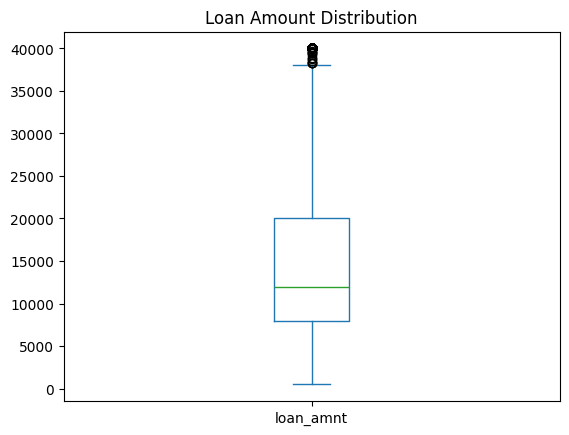

In [42]:
data['loan_amnt'].plot(kind='box', title='Loan Amount Distribution')

The min being 500 and Max being 40000 for the variable loan_amt we have enough evidence to say loan_amt is right skewed with few outliers and no suspicious/erroneous values.

GPT

loan_amnt ranges from 500 to 40,000 and exhibits right skewness. The upper range does not show obvious evidence of erroneous values. The maximum of 40,000 may represent a lending/product limit and should not automatically be treated as an outlier.

In [43]:
print(
    data[(data['int_rate']<0) | (data['int_rate']==0)],
    data['int_rate'].quantile([0.9, 0.93, 0.95, 0.97, 0.99,0.995,0.999, 1.0]),
    data['int_rate'].quantile([0,0.001, 0.01,0.025, 0.05, 0.075,0.09, 0.1])
)


Empty DataFrame
Columns: [loan_amnt, term, int_rate, installment, grade, sub_grade, emp_title, emp_length, home_ownership, annual_inc, verification_status, issue_d, loan_status, purpose, title, dti, earliest_cr_line, open_acc, pub_rec, revol_bal, revol_util, total_acc, initial_list_status, application_type, mort_acc, pub_rec_bankruptcies, address]
Index: [] 0.900    19.52
0.930    20.75
0.950    21.97
0.970    23.28
0.990    25.28
0.995    25.83
0.999    27.99
1.000    30.99
Name: int_rate, dtype: float64 0.000    5.32
0.001    5.32
0.010    6.00
0.025    6.03
0.050    6.89
0.075    7.49
0.090    7.66
0.100    7.89
Name: int_rate, dtype: float64


<Axes: xlabel='int_rate'>

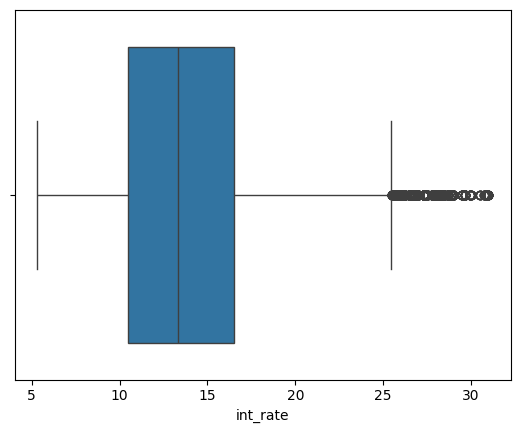

In [44]:
sns.boxplot(x='int_rate', data=data)

<Axes: xlabel='int_rate', ylabel='Count'>

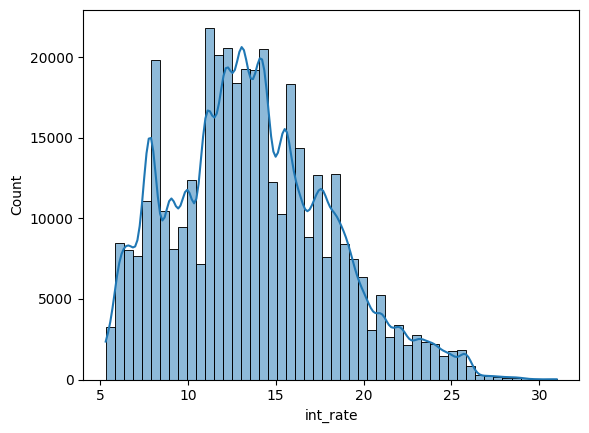

In [45]:
sns.histplot(x='int_rate', data=data, bins=50, kde=True)

We have enough evidence to conclude that Int_rate is a slightly right skewed with outliers and has no suspicious or misrepresenting values.

GPT

int_rate shows a mildly right-skewed distribution with some statistical outliers under the chosen outlier criterion. The observed range appears plausible for a personal-loan product, with no obvious invalid values identified.

In [46]:
print(
    data[(data['installment']<0) | (data['installment']==0)],
    data['installment'].quantile([0.9, 0.93, 0.95, 0.97, 0.99,0.995,0.999, 1.0]),
    data['installment'].quantile([0,0.001, 0.01,0.025, 0.05, 0.075,0.09, 0.1])
)

Empty DataFrame
Columns: [loan_amnt, term, int_rate, installment, grade, sub_grade, emp_title, emp_length, home_ownership, annual_inc, verification_status, issue_d, loan_status, purpose, title, dti, earliest_cr_line, open_acc, pub_rec, revol_bal, revol_util, total_acc, initial_list_status, application_type, mort_acc, pub_rec_bankruptcies, address]
Index: [] 0.900     785.4800
0.930     861.4000
0.950     925.6000
0.970    1028.8013
0.990    1202.3730
0.995    1249.5900
0.999    1309.6600
1.000    1533.8100
Name: installment, dtype: float64 0.000     16.08000
0.001     32.64087
0.010     54.43000
0.025     80.29000
0.050    109.51000
0.075    136.68000
0.090    152.35000
0.100    158.86000
Name: installment, dtype: float64


<Axes: xlabel='installment'>

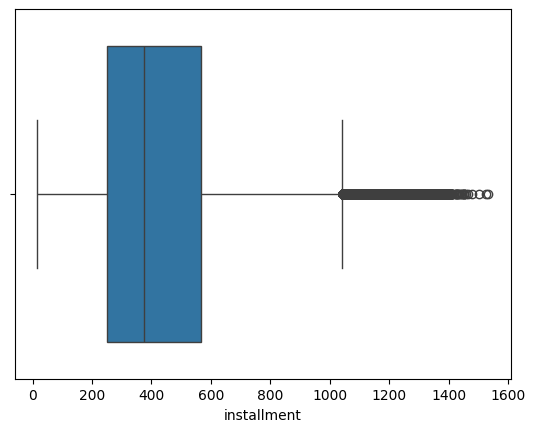

In [47]:
sns.boxplot(x='installment', data=data)

<Axes: xlabel='installment', ylabel='Count'>

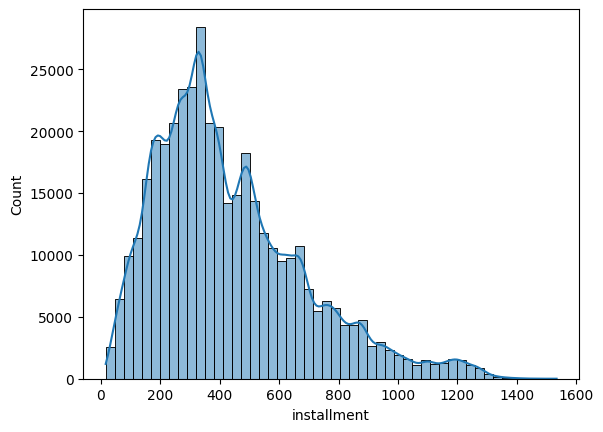

In [48]:
sns.histplot(x='installment', data=data, bins=50, kde=True)

In [49]:
data[(data['revol_bal']<0) ]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address


In [50]:
data[(data['revol_bal']==0) ].describe().T

,count,mean,min,25%,50%,75%,max,std
loan_amnt,2128.0,11096.804511,700.0,5000.0,8462.5,15000.0,40000.0,8460.2689
int_rate,2128.0,12.815808,5.32,8.9,12.29,15.8,30.94,4.805696
installment,2128.0,334.497989,23.35,154.18,265.68,456.54,1408.13,248.365471
annual_inc,2128.0,72292.229328,4800.0,40000.0,60000.0,86883.0,850000.0,57183.742712
issue_d,2128,2013-02-06 19:36:05.413533952,2007-07-01 00:00:00,2011-05-01 00:00:00,2013-04-01 00:00:00,2015-02-01 00:00:00,2016-12-01 00:00:00,NaN
dti,2128.0,10.782345,0.0,4.3175,9.955,16.2725,39.78,8.167669
earliest_cr_line,2128,1999-02-16 12:26:23.458646528,1954-11-01 00:00:00,1995-11-01 00:00:00,2000-02-01 00:00:00,2003-12-01 00:00:00,2013-05-01 00:00:00,NaN
open_acc,2128.0,6.396147,0.0,4.0,6.0,8.0,32.0,3.889581
pub_rec,2128.0,0.104793,0.0,0.0,0.0,0.0,8.0,0.405435
revol_bal,2128.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
print(
    data['revol_bal'].quantile([0.9, 0.93, 0.95, 0.97, 0.99,0.995,0.999, 1.0]),
    data['revol_bal'].quantile([0,0.001, 0.01,0.025, 0.05, 0.075,0.09, 0.1])
)

0.900      31470.000
0.930      36278.000
0.950      41066.550
0.970      50070.260
0.990      86039.620
0.995     120752.775
0.999     250130.765
1.000    1743266.000
Name: revol_bal, dtype: float64 0.000       0.0
0.001       0.0
0.010     154.0
0.025     787.0
0.050    1685.0
0.075    2440.0
0.090    2856.0
0.100    3091.0
Name: revol_bal, dtype: float64


<Axes: title={'center': 'Revolving Balance Distribution'}>

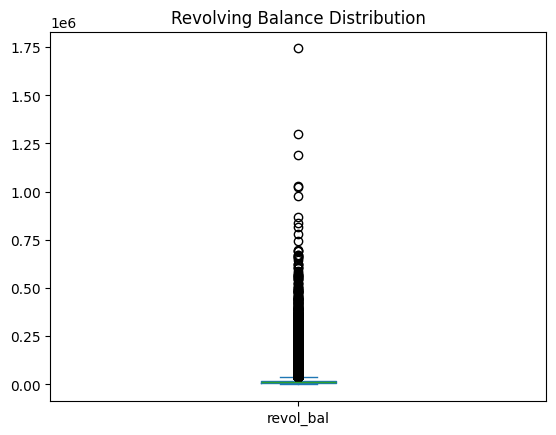

In [52]:
data['revol_bal'].plot(kind='box', title='Revolving Balance Distribution')

<Axes: xlabel='revol_bal', ylabel='Count'>

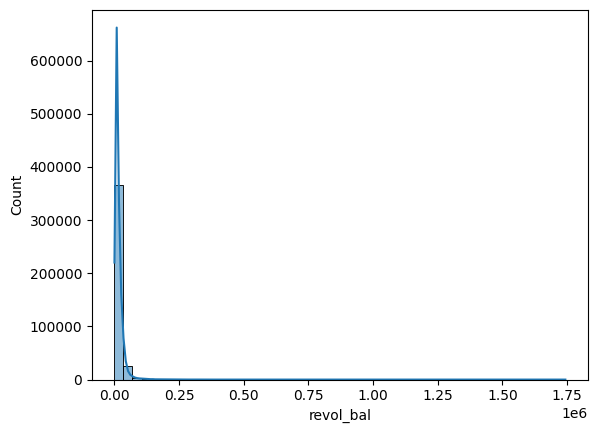

In [53]:
sns.histplot(x='revol_bal', data=data, bins=50, kde=True)

In [54]:
data[data['revol_bal']==0].shape[0]/data.shape[0]*100

0.5373330303259853

In [55]:
data[data['revol_bal']==1743266.000]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
118582,35000.0,36 months,11.14,1148.18,B,B2,plastic surgery,10+ years,MORTGAGE,400000.0,Verified,2013-01-01,Fully Paid,debt_consolidation,consolidation,33.48,1984-07-01,28.0,0.0,1743266.0,29.5,59.0,f,INDIVIDUAL,6.0,0.0,81070 Meredith Fort Apt. 334\r\nNew Stephaniev...


In [56]:
upper_whisker = data['revol_bal'].quantile(0.75) + 1.5 * (data['revol_bal'].quantile(0.75) - data['revol_bal'].quantile(0.25))
print(f"Upper Whisker for Revolving Balance: {upper_whisker}")

Upper Whisker for Revolving Balance: 40012.5


In [57]:
data[data['revol_bal']>40012.5].shape[0]/data.shape[0]*100

5.368027674671111

In [58]:
lower_whisker = data['revol_bal'].quantile(0.25) - 1.5 * (data['revol_bal'].quantile(0.75) - data['revol_bal'].quantile(0.25))
print(f"Lower Whisker for Revolving Balance: {lower_whisker}" if lower_whisker > 0 else "Lower Whisker for Revolving Balance: 0 (Adjusted to 0 since it cannot be negative)")

Lower Whisker for Revolving Balance: 0 (Adjusted to 0 since it cannot be negative)


In [59]:
data[(data['revol_bal']==0) & (data['total_acc']==0)].shape[0]

0

The feature revol_bal has 0 for about 0.5% of the records suggesting that about 0.5% of the applicants have repaid all their credit dues for the existing bill cycle.
We also observe that the feature revol_bal is extremely right skewed and has a very heavy right tail, with about 5.4% of data being outliers.
The Extreme value 1.7Million do not seem to be a error because of the presence of evidence of 400K annual income and the profession of a plastic surgeon with more than 10 years practice.

Gpt

Approximately 0.5% of observations have a revolving balance of zero, indicating no reported revolving balance.

The maximum revolving balance (~1.74M) is an extreme observation, but inspection of the corresponding applicant's income and employment characteristics provides contextual evidence that the value could be legitimate. No internal inconsistency was identified, so it is retained provisionally.

In [60]:
data[(data['total_acc']==0) | (data['total_acc']<0)]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address


In [61]:
print(
    data['total_acc'].quantile([0.9, 0.93, 0.95, 0.97, 0.99,0.995,0.999,0.9999, 1.0]),
    data['total_acc'].quantile([0,0.001, 0.01,0.025, 0.05, 0.075,0.09, 0.1])
)

0.9000     41.0
0.9300     44.0
0.9500     47.0
0.9700     52.0
0.9900     60.0
0.9950     63.0
0.9990     77.0
0.9999     97.0
1.0000    151.0
Name: total_acc, dtype: float64 0.000     2.0
0.001     4.0
0.010     6.0
0.025     7.0
0.050     9.0
0.075    10.0
0.090    11.0
0.100    12.0
Name: total_acc, dtype: float64


In [62]:
data[data['total_acc']==151]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
105682,35000.0,36 months,13.99,1196.05,C,C4,Sr Operator,3 years,RENT,160000.0,Verified,2015-10-01,Charged Off,debt_consolidation,Debt consolidation,12.65,2002-06-01,26.0,0.0,46643.0,71.5,151.0,w,INDIVIDUAL,0.0,0.0,"37001 Park Station\r\nDonnaport, SD 86630"


<Axes: title={'center': 'Total Accounts Distribution'}>

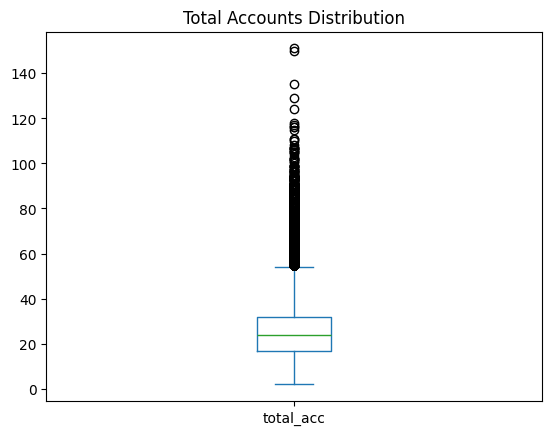

In [63]:
data['total_acc'].plot(kind='box', title='Total Accounts Distribution')

<Axes: title={'center': 'Total Accounts Distribution'}, ylabel='Density'>

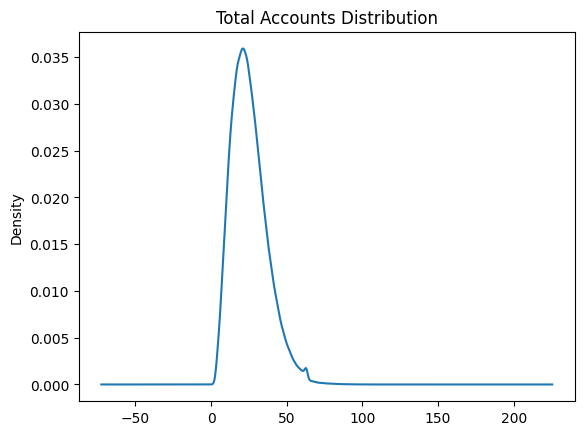

In [64]:
data['total_acc'].plot(kind='kde', title='Total Accounts Distribution')

<Axes: xlabel='total_acc', ylabel='Count'>

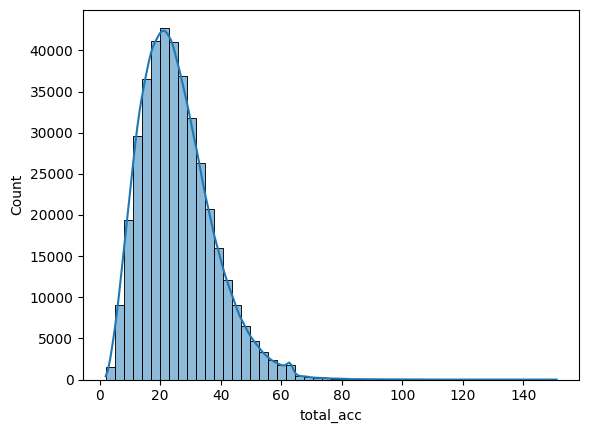

In [65]:
sns.histplot(x='total_acc', data=data, bins=50,kde=True)

In [66]:
data['total_acc'].value_counts().sort_values(ascending=False)

total_acc
21.0     14280
22.0     14260
20.0     14228
23.0     13923
24.0     13878
         ...  
150.0        1
117.0        1
115.0        1
100.0        1
103.0        1
Name: count, Length: 118, dtype: int64

In [67]:
data[data['total_acc']>54.5].shape[0]/data.shape[0]*100

2.1460495417013865

In [68]:
upper_whisker = data['total_acc'].quantile(0.75) + 1.5 * (data['total_acc'].quantile(0.75) - data['total_acc'].quantile(0.25))
print(f"Upper Whisker for Total Accounts: {upper_whisker}")

Upper Whisker for Total Accounts: 54.5


In [69]:
lower_whisker = data['total_acc'].quantile(0.25) - 1.5 * (data['total_acc'].quantile(0.75) - data['total_acc'].quantile(0.25))
print(f"Lower Whisker for Total Accounts: {lower_whisker}" if lower_whisker > 0 else "Lower Whisker for Total Accounts: 0 (Adjusted to 0 since it cannot be negative)")

Lower Whisker for Total Accounts: 0 (Adjusted to 0 since it cannot be negative)


There is enough evidence to suggest there are no erroneous data for the feature 'total_acc' and the extreme value 151 seem to be consistant with the rest of the data of the applicant. The feature total_acc has a right tail, with 2.1% of the data being outliers.

GPT

"No obvious erroneous values were identified."

total_acc is right-skewed with a long upper tail. Approximately 2.1% of observations are statistical outliers under the selected criterion. The maximum of 151 was investigated and appears internally consistent with the applicant's other credit characteristics; therefore, no removal is currently justified.

In [70]:
data[ (data['mort_acc']<0)]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address


In [71]:
print(
    data['mort_acc'].quantile([0.9, 0.93, 0.95, 0.97, 0.99,0.995,0.999,0.9999, 1.0]),
    data['mort_acc'].quantile([0,0.001, 0.01,0.025, 0.05, 0.075,0.09, 0.1])
)

0.9000     5.0
0.9300     5.0
0.9500     6.0
0.9700     7.0
0.9900     9.0
0.9950    10.0
0.9990    13.0
0.9999    21.0
1.0000    34.0
Name: mort_acc, dtype: float64 0.000    0.0
0.001    0.0
0.010    0.0
0.025    0.0
0.050    0.0
0.075    0.0
0.090    0.0
0.100    0.0
Name: mort_acc, dtype: float64


<Axes: title={'center': 'Mortgage Accounts Distribution'}>

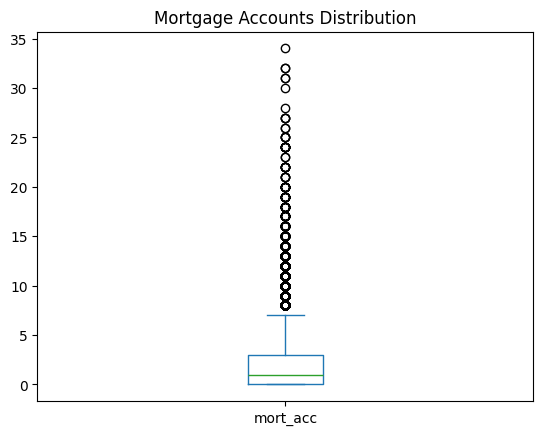

In [72]:
data['mort_acc'].plot(kind='box', title='Mortgage Accounts Distribution')

In [73]:
data['mort_acc'].dtype,data['total_acc'].dtype

(dtype('float64'), dtype('float64'))

<Axes: xlabel='mort_acc', ylabel='Count'>

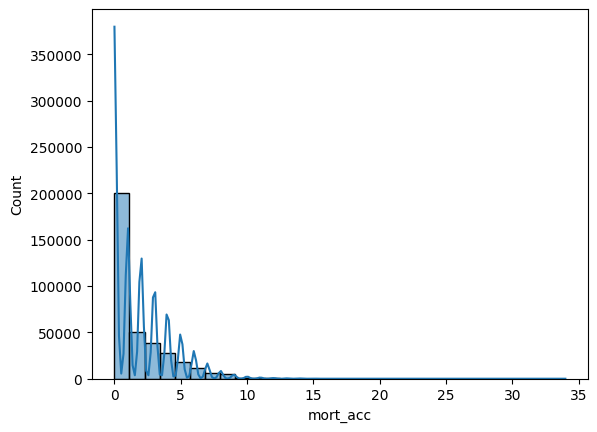

In [74]:
sns.histplot(x='mort_acc', data=data,kde=True,bins=30)

In [75]:
data['mort_acc'].value_counts().sort_values(ascending=False)

mort_acc
0.0     139777
1.0      60416
2.0      49948
3.0      38049
4.0      27887
5.0      18194
6.0      11069
7.0       6052
8.0       3121
9.0       1656
10.0       865
11.0       479
12.0       264
13.0       146
14.0       107
15.0        61
16.0        37
17.0        22
18.0        18
19.0        15
20.0        13
24.0        10
22.0         7
21.0         4
25.0         4
27.0         3
26.0         2
32.0         2
31.0         2
23.0         2
34.0         1
28.0         1
30.0         1
Name: count, dtype: int64

In [76]:
data['mort_acc'].value_counts().sort_values(ascending=False)[0]/data.shape[0]*100

np.float64(35.294548392798525)

In [77]:
upper_whisker = data['mort_acc'].quantile(0.75) + 1.5 * (data['mort_acc'].quantile(0.75) - data['mort_acc'].quantile(0.25))
print(f"Upper Whisker for Mortgage Accounts: {upper_whisker}")

Upper Whisker for Mortgage Accounts: 7.5


In [78]:
lower_whisker = data['mort_acc'].quantile(0.25) - 1.5 * (data['mort_acc'].quantile(0.75) - data['mort_acc'].quantile(0.25))
print(f"Lower Whisker for Mortgage Accounts: {lower_whisker}" if lower_whisker > 0 else "Lower Whisker for Mortgage Accounts: 0 (Adjusted to 0 since it cannot be negative)")

Lower Whisker for Mortgage Accounts: 0 (Adjusted to 0 since it cannot be negative)


In [79]:
data[data['mort_acc']>7.5].shape[0]/data.shape[0]*100

1.7278994015604878

 About 35.3% of the population has mort_acc = 0. There is evidence to conclude that there are about 1.7% of data are outliers and The data distribution is right skewed and has a heavy right tail for the feature mort_acc.There are no erronous or misrepresenting data values found.

In [80]:
data[ (data['pub_rec_bankruptcies']<0)]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address


In [81]:
print(
    data['pub_rec_bankruptcies'].quantile([0.9, 0.93, 0.95, 0.97, 0.99,0.995,0.999,0.9999, 1.0]),
    data['pub_rec_bankruptcies'].quantile([0,0.001, 0.01,0.025, 0.05, 0.075,0.09, 0.1])
)

0.9000    1.0
0.9300    1.0
0.9500    1.0
0.9700    1.0
0.9900    1.0
0.9950    2.0
0.9990    3.0
0.9999    5.0
1.0000    8.0
Name: pub_rec_bankruptcies, dtype: float64 0.000    0.0
0.001    0.0
0.010    0.0
0.025    0.0
0.050    0.0
0.075    0.0
0.090    0.0
0.100    0.0
Name: pub_rec_bankruptcies, dtype: float64


In [82]:
data['pub_rec_bankruptcies'].value_counts(normalize=True).sort_values(ascending=False)

pub_rec_bankruptcies
0.0    0.885928
1.0    0.108194
2.0    0.004670
3.0    0.000887
4.0    0.000207
5.0    0.000081
6.0    0.000018
7.0    0.000010
8.0    0.000005
Name: proportion, dtype: float64

<Axes: title={'center': 'Public Record Bankruptcies Distribution'}, xlabel='pub_rec_bankruptcies'>

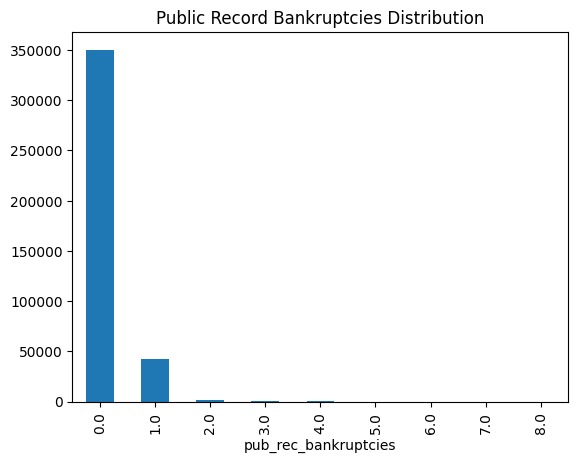

In [83]:
data['pub_rec_bankruptcies'].value_counts().plot(kind='bar', title='Public Record Bankruptcies Distribution')

The Feature pub_rec_bankruptcies has no erroneous values, and about 88% of the population has 0 public records of banckruptcies and about 10% of the population has 1 public record of bankruptcy.

In [84]:
data[(data['installment']==0) | (data['installment']<0)]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address


In [85]:
data.nlargest(10, 'installment')[['installment','loan_amnt','loan_status','int_rate']]

,installment,loan_amnt,loan_status,int_rate
6093,1533.81,38225.0,Fully Paid,25.69
26653,1527.00,40000.0,Charged Off,21.97
297246,1503.85,38275.0,Fully Paid,24.11
67022,1479.49,35000.0,Fully Paid,29.67
364038,1464.42,35000.0,Fully Paid,28.88
373897,1458.25,34025.0,Fully Paid,30.74
81015,1451.14,35000.0,Fully Paid,28.18
253470,1451.14,35000.0,Fully Paid,28.18
13966,1451.12,40000.0,Fully Paid,18.25
254547,1451.12,40000.0,Fully Paid,18.25


<Axes: title={'center': 'Installment Distribution'}>

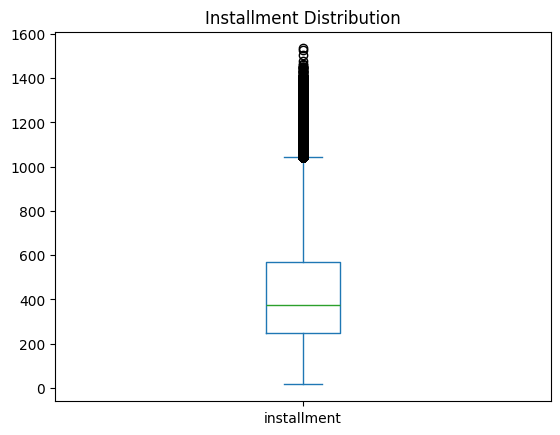

In [86]:
data['installment'].plot(kind='box', title='Installment Distribution')